In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('TaxiData.csv')

```
Analysis on overall Dataset.
Provide info about columns and its Datatypes.
State missing values and other organic analysis.
```

## Q 1.a Categorise columns

In [3]:
# Check data shape, summary, ...

# Identify missing values
# Plot missing values (customize as needed)
# missing_values.plot(...)

# Any change of data type conversion required?


In [4]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15002 entries, 0 to 15001
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pickup_community_area   15000 non-null  float64
 1   fare                    15002 non-null  float64
 2   trip_start_month        15002 non-null  int64  
 3   trip_start_hour         15002 non-null  int64  
 4   trip_start_day          15002 non-null  int64  
 5   trip_start_timestamp    15002 non-null  int64  
 6   pickup_latitude         15000 non-null  float64
 7   pickup_longitude        15000 non-null  float64
 8   dropoff_latitude        14520 non-null  float64
 9   dropoff_longitude       14520 non-null  float64
 10  trip_miles              15002 non-null  float64
 11  pickup_census_tract     1 non-null      float64
 12  dropoff_census_tract    10761 non-null  float64
 13  payment_type            15002 non-null  object 
 14  company                 

```
Categorical:
pickup_community_area, payment_type, company
Numerical:
fare, trip_start_month, trip_start_hour, trip_start_day, trip_start_timestamp, pickup_latitude, pickup_longitude, dropoff_latitude, dropoff_longitude, trip_miles, pickup_census_tract, dropoff_census_tract, trip_seconds, dropoff_community_area, tips
```

## Type Conversion

In [5]:
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'], unit='s')

df['pickup_community_area'] = df['pickup_community_area'].astype('category')
df['dropoff_community_area'] = df['dropoff_community_area'].astype('category')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
pickup_community_area           category
fare                             float64
trip_start_month                   int64
trip_start_hour                    int64
trip_start_day                     int64
trip_start_timestamp      datetime64[ns]
pickup_latitude                  float64
pickup_longitude                 float64
dropoff_latitude                 float64
dropoff_longitude                float64
trip_miles                       float64
pickup_census_tract              float64
dropoff_census_tract             float64
payment_type                      object
company                           object
trip_seconds                     float64
dropoff_community_area          category
tips                             float64
dtype: object


## Identify Missing Values and Visualize

Missing Values in Each Column:
pickup_community_area         2
fare                          0
trip_start_month              0
trip_start_hour               0
trip_start_day                0
trip_start_timestamp          0
pickup_latitude               2
pickup_longitude              2
dropoff_latitude            482
dropoff_longitude           482
trip_miles                    0
pickup_census_tract       15001
dropoff_census_tract       4241
payment_type                  0
company                    5140
trip_seconds                  6
dropoff_community_area      506
tips                          0
dtype: int64


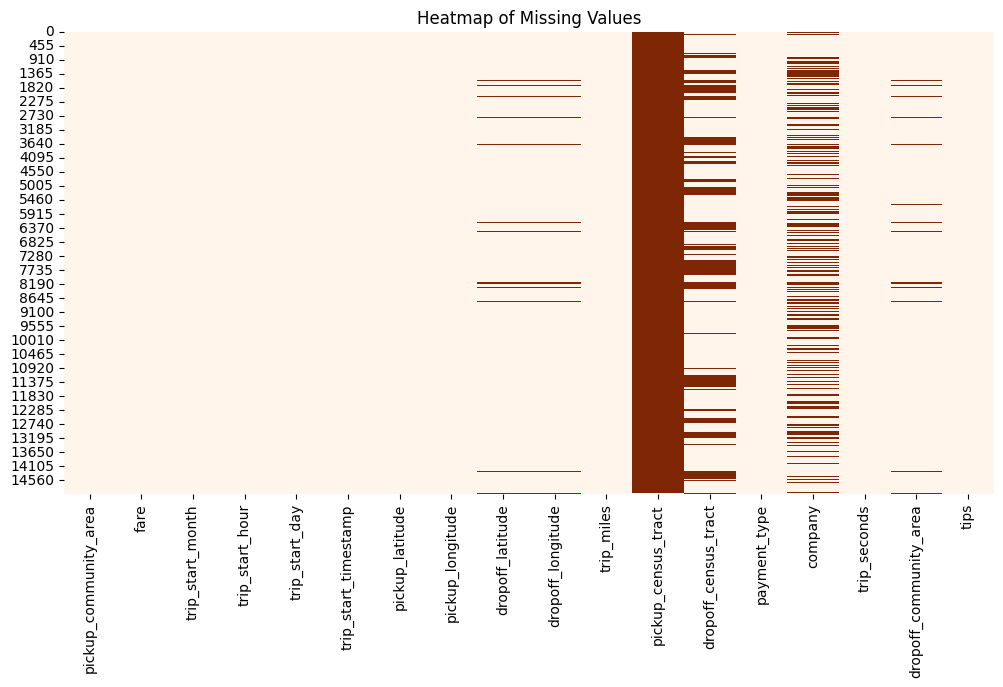

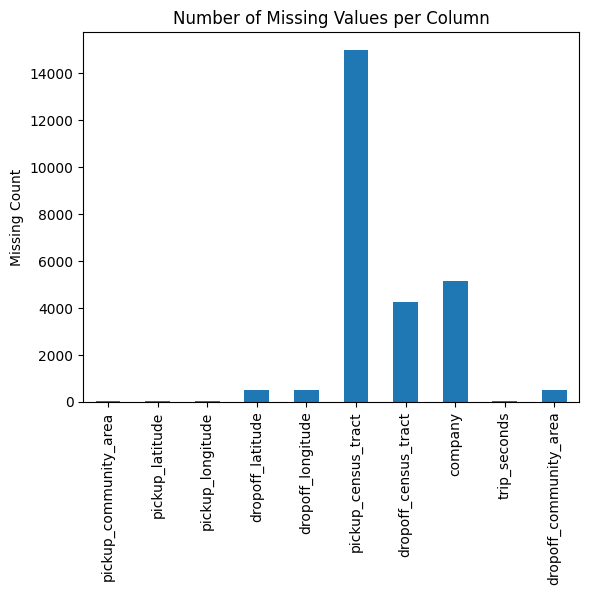

In [6]:
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='Oranges')
plt.title('Heatmap of Missing Values')
plt.show()

missing_values[missing_values > 0].plot(kind='bar')
plt.title('Number of Missing Values per Column')
plt.ylabel('Missing Count')
plt.show()

As observed from the plots 'pickup_census_tract' has largest number of missing values followed by 'company' and 'dropoff_census_tract' respectively.

## Handling Missing Values
We will use the following methods:<br>
1.) ['fare', 'trip_miles', 'trip_seconds', 'tips'] := Mean imputation<br>
2.) ['payment_type', 'company','pickup_census_tract','dropoff_census_tract'] := label 'Unknown' imputation <br>
3.) ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'] := Dropping critical values

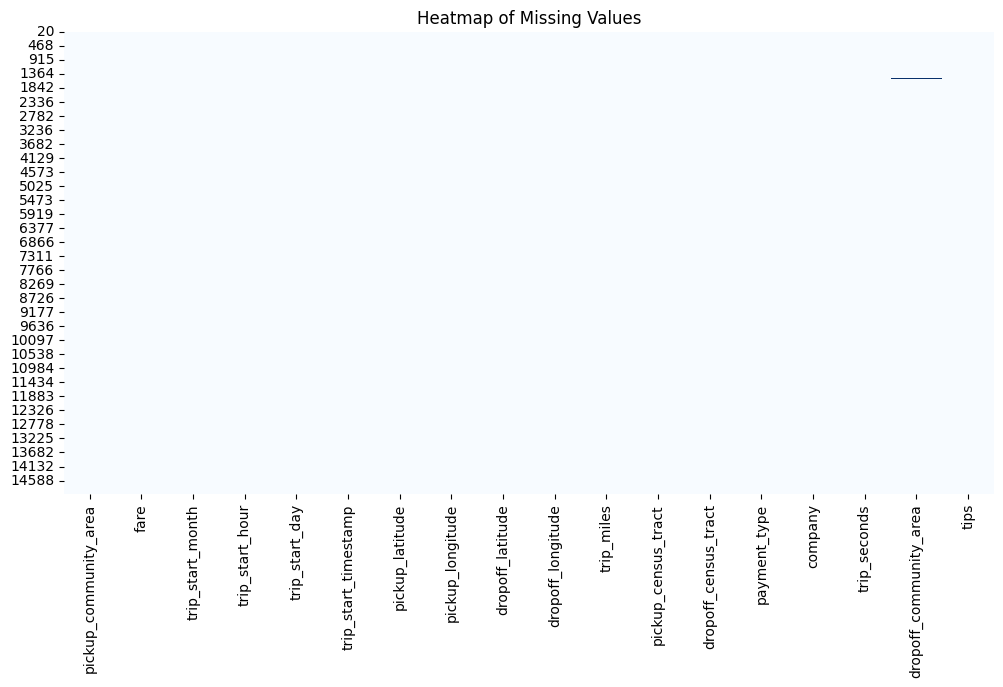

In [7]:
import warnings
warnings.filterwarnings("ignore")
numerical_cols = ['fare', 'trip_miles', 'trip_seconds', 'tips']
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

categorical_cols = ['payment_type', 'company','pickup_census_tract','dropoff_census_tract']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'], inplace=True)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='Blues')
plt.title('Heatmap of Missing Values')
plt.show()